# Diabetes Disease Classification Using Machine Learning


## 1. Imports And Global Settings


In [1]:
import os
import warnings

import joblib
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.base import clone
from sklearn.ensemble import AdaBoostClassifier, RandomForestClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.exceptions import ConvergenceWarning
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    accuracy_score, confusion_matrix, f1_score, log_loss, precision_score,
    recall_score, roc_auc_score, roc_curve
)
from sklearn.model_selection import (
    GridSearchCV, StratifiedKFold, cross_val_score, learning_curve,
    train_test_split
)
from sklearn.naive_bayes import GaussianNB
from sklearn.neural_network import MLPClassifier
from sklearn.preprocessing import StandardScaler
from sklearn.svm import SVC

from imblearn.over_sampling import SMOTE

warnings.filterwarnings("ignore", category=ConvergenceWarning)
warnings.filterwarnings("ignore", category=UserWarning)
warnings.filterwarnings("ignore", category=FutureWarning)

sns.set_theme(style="whitegrid", context="notebook")
plt.rcParams["figure.figsize"] = (7, 4)

RANDOM_STATE = 42
MIN_RECALL = 0.80
VALIDATION_RECALL_FLOOR = MIN_RECALL
THRESHOLD_F1_TOLERANCE = 0.003
CV = StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)
THRESHOLDS = np.round(np.arange(0.01, 0.951, 0.002), 3)

model_results = []
model_registry = {}

## 2. Data Understanding And Preprocessing


Raw dataset shape: (100000, 9)


,gender,age,hypertension,heart_disease,smoking_history,bmi,HbA1c_level,blood_glucose_level,diabetes
0,Female,80.0,0,1,never,25.19,6.6,140,0
1,Female,54.0,0,0,No Info,27.32,6.6,80,0
2,Male,28.0,0,0,never,27.32,5.7,158,0
3,Female,36.0,0,0,current,23.45,5.0,155,0
4,Male,76.0,1,1,current,20.14,4.8,155,0


,count,unique,top,freq,mean,std,min,25%,50%,75%,max
gender,100000,3,Female,58552,NaN,NaN,NaN,NaN,NaN,NaN,NaN
age,100000.0,NaN,NaN,NaN,41.885856,22.51684,0.08,24.0,43.0,60.0,80.0
hypertension,100000.0,NaN,NaN,NaN,0.07485,0.26315,0.0,0.0,0.0,0.0,1.0
heart_disease,100000.0,NaN,NaN,NaN,0.03942,0.194593,0.0,0.0,0.0,0.0,1.0
smoking_history,100000,6,No Info,35816,NaN,NaN,NaN,NaN,NaN,NaN,NaN
bmi,100000.0,NaN,NaN,NaN,27.320767,6.636783,10.01,23.63,27.32,29.58,95.69
HbA1c_level,100000.0,NaN,NaN,NaN,5.527507,1.070672,3.5,4.8,5.8,6.2,9.0
blood_glucose_level,100000.0,NaN,NaN,NaN,138.05806,40.708136,80.0,100.0,140.0,159.0,300.0
diabetes,100000.0,NaN,NaN,NaN,0.085,0.278883,0.0,0.0,0.0,0.0,1.0


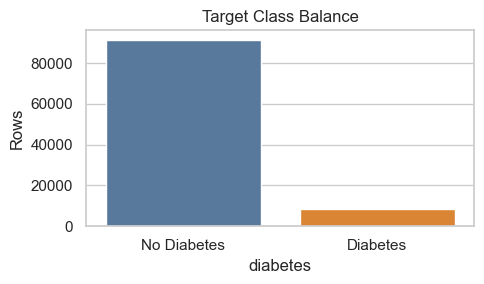

Positive diabetes rate: 8.50%
Duplicate rows: 3854
Missing values:
gender                 0
age                    0
hypertension           0
heart_disease          0
smoking_history        0
bmi                    0
HbA1c_level            0
blood_glucose_level    0
diabetes               0
dtype: int64


In [2]:
df_raw = pd.read_csv("diabetes_prediction_dataset.csv")
print(f"Raw dataset shape: {df_raw.shape}")
display(df_raw.head())
display(df_raw.describe(include="all").T)

target_counts = df_raw["diabetes"].value_counts().rename(index={0: "No Diabetes", 1: "Diabetes"})
fig, ax = plt.subplots(figsize=(5, 3))
sns.barplot(x=target_counts.index, y=target_counts.values, hue=target_counts.index,
            palette=["#4C78A8", "#F58518"], legend=False, ax=ax)
ax.set_title("Target Class Balance")
ax.set_ylabel("Rows")
plt.tight_layout()
plt.show()

print(f"Positive diabetes rate: {df_raw['diabetes'].mean():.2%}")
print(f"Duplicate rows: {df_raw.duplicated().sum()}")
print("Missing values:")
print(df_raw.isna().sum())

In [3]:
df_clean = df_raw.drop_duplicates().copy()
df_clean = df_clean[df_clean["age"] >= 1].copy()

bmi_low, bmi_high = df_clean["bmi"].quantile([0.01, 0.99])
df_clean["bmi"] = df_clean["bmi"].clip(bmi_low, bmi_high)

smoking_map = {
    "never": "never",
    "current": "current",
    "former": "past",
    "ever": "past",
    "not current": "past",
    "No Info": "unknown",
}
df_clean["smoking_history"] = df_clean["smoking_history"].map(smoking_map).fillna("unknown")
df_clean = df_clean[df_clean["gender"].isin(["Male", "Female"])].copy()
df_clean["gender"] = df_clean["gender"].map({"Female": 0, "Male": 1}).astype(int)

# Keep the strongest combined medical signal as one engineered feature.
df_clean["hba1c_glucose_interaction"] = df_clean["HbA1c_level"] * df_clean["blood_glucose_level"]

df_encoded = pd.get_dummies(
    df_clean,
    columns=["smoking_history"],
    drop_first=False,
    dtype=int,
)
X = df_encoded.drop(columns=["diabetes"])
y = df_encoded["diabetes"].astype(int)

X_temp, X_test, y_temp, y_test = train_test_split(
    X, y, test_size=0.20, stratify=y, random_state=RANDOM_STATE
)
X_train, X_val, y_train, y_val = train_test_split(
    X_temp, y_temp, test_size=0.125, stratify=y_temp, random_state=RANDOM_STATE
)

continuous_features = [
    "age", "bmi", "HbA1c_level", "blood_glucose_level", "hba1c_glucose_interaction",
]
continuous_features = [c for c in continuous_features if c in X_train.columns]

scaler = StandardScaler()
X_train_scaled = X_train.copy()
X_val_scaled = X_val.copy()
X_test_scaled = X_test.copy()
X_train_scaled[continuous_features] = scaler.fit_transform(X_train[continuous_features])
X_val_scaled[continuous_features] = scaler.transform(X_val[continuous_features])
X_test_scaled[continuous_features] = scaler.transform(X_test[continuous_features])

print(f"Cleaned shape: {df_clean.shape}")
print(f"Encoded feature count: {X.shape[1]}")
print(f"Train: {X_train_scaled.shape} | Validation: {X_val_scaled.shape} | Test: {X_test_scaled.shape}")
print(pd.Series({
    "Train positive rate": y_train.mean(),
    "Validation positive rate": y_val.mean(),
    "Test positive rate": y_test.mean(),
}).map(lambda v: f"{v:.2%}"))

Cleaned shape: (95218, 10)
Encoded feature count: 12
Train: (66652, 12) | Validation: (9522, 12) | Test: (19044, 12)
Train positive rate         8.91%
Validation positive rate    8.91%
Test positive rate          8.91%
dtype: str


## 3. Shared Helper Functions


In [4]:
def get_scores(model, X_data):
    if hasattr(model, "predict_proba"):
        return model.predict_proba(X_data)[:, 1]
    if hasattr(model, "decision_function"):
        scores = model.decision_function(X_data)
        return (scores - scores.min()) / (scores.max() - scores.min() + 1e-12)
    raise TypeError(f"{type(model).__name__} has no probability or decision score output.")


def score_at_threshold(y_true, scores, threshold):
    pred = (scores >= threshold).astype(int)
    return {
        "accuracy": accuracy_score(y_true, pred),
        "precision": precision_score(y_true, pred, zero_division=0),
        "recall": recall_score(y_true, pred, zero_division=0),
        "f1": f1_score(y_true, pred, zero_division=0),
        "roc_auc": roc_auc_score(y_true, scores),
        "confusion_matrix": confusion_matrix(y_true, pred),
    }


def tune_threshold(y_true, scores, min_recall=MIN_RECALL, f1_tolerance=THRESHOLD_F1_TOLERANCE):
    """Choose a realistic threshold on validation data.

    Primary rule: maximize F1 while keeping recall >= min_recall.
    Tie-break rule: if thresholds are within a tiny F1 tolerance, prefer the
    threshold with higher precision. This improves the recall-precision balance
    instead of choosing an unnecessarily low threshold.
    """
    rows = []
    for threshold in THRESHOLDS:
        metrics = score_at_threshold(y_true, scores, threshold)
        rows.append({
            "threshold": float(threshold),
            "f1": metrics["f1"],
            "precision": metrics["precision"],
            "recall": metrics["recall"],
            "accuracy": metrics["accuracy"],
            "positive_predictions": int((scores >= threshold).sum()),
        })

    curve = pd.DataFrame(rows)
    safe = curve[curve["recall"] >= min_recall].copy()

    if len(safe):
        max_f1 = safe["f1"].max()
        finalists = safe[safe["f1"] >= max_f1 - f1_tolerance].copy()
        best = finalists.sort_values(
            ["precision", "f1", "threshold"],
            ascending=[False, False, False],
        ).iloc[0]
        selection_note = f"max F1 with recall >= {min_recall:.0%}, precision tie-break"
    else:
        best = curve.sort_values(["recall", "f1", "precision"], ascending=False).iloc[0]
        selection_note = f"fallback: no threshold reached recall >= {min_recall:.0%}"

    curve["selected"] = curve["threshold"].eq(float(best["threshold"]))
    curve.attrs["selection_note"] = selection_note
    return float(best["threshold"]), curve


def make_training_data(X_data, y_data, imbalance="none", sample_size=None):
    X_fit, y_fit = X_data, y_data
    if imbalance == "smote":
        X_fit, y_fit = SMOTE(random_state=RANDOM_STATE).fit_resample(X_fit, y_fit)
    if sample_size is not None and len(X_fit) > sample_size:
        rng = np.random.default_rng(RANDOM_STATE)
        idx = rng.choice(len(X_fit), size=sample_size, replace=False)
        X_fit = X_fit.iloc[idx] if hasattr(X_fit, "iloc") else X_fit[idx]
        y_fit = y_fit.iloc[idx] if hasattr(y_fit, "iloc") else y_fit[idx]
    return X_fit, y_fit


def fit_grid_search(model, param_grid, X_fit, y_fit, scoring="f1", name="Model"):
    search = GridSearchCV(
        model,
        param_grid=param_grid,
        scoring=scoring,
        cv=CV,
        n_jobs=-1,
        refit=True,
        return_train_score=True,
    )
    search.fit(X_fit, y_fit)
    print(f"{name} best CV {scoring}: {search.best_score_:.4f}")
    print(f"{name} best params: {search.best_params_}")
    return search


def evaluate_and_register(name, model, X_tr, y_tr, X_va, y_va, X_te, y_te, notes="", min_recall=MIN_RECALL):
    val_scores = get_scores(model, X_va)
    best_threshold, threshold_curve = tune_threshold(y_va, val_scores, min_recall=min_recall)
    default_val_metrics = score_at_threshold(y_va, val_scores, 0.50)
    tuned_val_metrics = score_at_threshold(y_va, val_scores, best_threshold)

    split_metrics = {}
    for split_name, X_split, y_split in [
        ("train", X_tr, y_tr),
        ("validation", X_va, y_va),
        ("test", X_te, y_te),
    ]:
        split_metrics[split_name] = score_at_threshold(y_split, get_scores(model, X_split), best_threshold)

    record = {
        "model": name,
        "threshold": best_threshold,
        "train_f1": split_metrics["train"]["f1"],
        "val_f1": split_metrics["validation"]["f1"],
        "test_f1": split_metrics["test"]["f1"],
        "test_precision": split_metrics["test"]["precision"],
        "test_recall": split_metrics["test"]["recall"],
        "test_accuracy": split_metrics["test"]["accuracy"],
        "test_roc_auc": split_metrics["test"]["roc_auc"],
        "train_val_f1_gap": split_metrics["train"]["f1"] - split_metrics["validation"]["f1"],
        "recall_target_met": split_metrics["test"]["recall"] >= MIN_RECALL,
        "notes": notes,
    }

    model_registry[name] = {
        "model": model,
        "threshold": best_threshold,
        "threshold_curve": threshold_curve,
        "metrics": split_metrics,
        "X_train": X_tr,
        "X_val": X_va,
        "X_test": X_te,
        "y_train": y_tr,
        "y_val": y_va,
        "y_test": y_te,
        "record": record,
    }
    model_results.append(record)

    print(f"{name} selected threshold: {best_threshold:.3f}")
    print(f"Threshold rule: {threshold_curve.attrs.get('selection_note', 'F1 with recall constraint')}")
    print(
        "Validation threshold effect: "
        f"default F1={default_val_metrics['f1']:.4f}, P={default_val_metrics['precision']:.4f}, R={default_val_metrics['recall']:.4f} | "
        f"tuned F1={tuned_val_metrics['f1']:.4f}, P={tuned_val_metrics['precision']:.4f}, R={tuned_val_metrics['recall']:.4f}"
    )
    display(pd.DataFrame(split_metrics).T[["f1", "precision", "recall", "accuracy", "roc_auc"]].round(4))
    return record


def model_summary(name):
    return pd.DataFrame([model_registry[name]["record"]]).round(4)


def plot_threshold_curve(name):
    curve = model_registry[name]["threshold_curve"]
    threshold = model_registry[name]["threshold"]
    fig, ax = plt.subplots(figsize=(6, 3.4))
    ax.plot(curve["threshold"], curve["f1"], label="F1", color="#2F5597", lw=2)
    ax.plot(curve["threshold"], curve["precision"], label="Precision", color="#548235", lw=1.5)
    ax.plot(curve["threshold"], curve["recall"], label="Recall", color="#C55A11", lw=1.5)
    ax.axhline(MIN_RECALL, ls=":", color="#C55A11", lw=1, label=f"Test target {MIN_RECALL:.0%}")
    ax.axhline(VALIDATION_RECALL_FLOOR, ls="--", color="#C55A11", lw=0.8, alpha=0.55, label=f"Tuning floor {VALIDATION_RECALL_FLOOR:.0%}")
    ax.axvline(threshold, ls="--", color="black", lw=1, label=f"Selected {threshold:.3f}")
    ax.set_title(f"{name}: Threshold Tuning")
    ax.set_xlabel("Threshold")
    ax.set_ylabel("Score")
    ax.set_ylim(0, 1.02)
    ax.legend(fontsize=8, ncol=2)
    plt.tight_layout()
    plt.show()


def plot_confusion_matrix_for(name, split="test"):
    cm = model_registry[name]["metrics"][split]["confusion_matrix"]
    tn, fp, fn, tp = cm.ravel()

    # Match the lecture-style layout:
    # rows = predicted class, columns = actual class.
    # top-left is TP because Diabetes is the positive class.
    display_cm = np.array([
        [tp, fp],
        [fn, tn],
    ])

    fig, ax = plt.subplots(figsize=(4.2, 3.4))
    sns.heatmap(
        display_cm, annot=True, fmt="d", cmap="Blues", cbar=False,
        xticklabels=["Actual Diabetes", "Actual No Diabetes"],
        yticklabels=["Predicted Diabetes", "Predicted No Diabetes"],
        ax=ax,
    )
    ax.set_title(f"{name}: {split.title()} Confusion Matrix")
    ax.set_xlabel("Actual Class")
    ax.set_ylabel("Predicted Class")
    plt.tight_layout()
    plt.show()


def plot_learning_curve_for(name, estimator, X_data, y_data, scoring="f1", sample_size=12000):
    X_lc, y_lc = make_training_data(X_data, y_data, sample_size=sample_size)
    train_sizes, train_scores, val_scores = learning_curve(
        estimator,
        X_lc,
        y_lc,
        cv=CV,
        scoring=scoring,
        train_sizes=np.linspace(0.2, 1.0, 5),
        n_jobs=-1,
        shuffle=True,
        random_state=RANDOM_STATE,
    )
    train_mean = train_scores.mean(axis=1)
    val_mean = val_scores.mean(axis=1)
    fig, ax = plt.subplots(figsize=(5.8, 3.4))
    ax.plot(train_sizes, train_mean, marker="o", label="Train F1", color="#1B5E20")
    ax.plot(train_sizes, val_mean, marker="s", label="CV F1", color="#2F5597")
    ax.set_title(f"{name}: Learning Curve")
    ax.set_xlabel("Training examples")
    ax.set_ylabel("F1-score")
    ax.set_ylim(0, 1.02)
    ax.legend()
    plt.tight_layout()
    plt.show()
    print(f"Final learning-curve gap: {train_mean[-1] - val_mean[-1]:.4f}")


def svm_negative_hinge_scorer(estimator, X_data, y_data):
    y_signed = np.where(np.asarray(y_data) == 1, 1, -1)
    decision_scores = estimator.decision_function(X_data)
    hinge_losses = np.maximum(0, 1 - y_signed * decision_scores)
    return -hinge_losses.mean()


def plot_svm_hinge_loss_curve(name, estimator, X_data, y_data, sample_size=3000):
    X_lc, y_lc = make_training_data(X_data, y_data, sample_size=sample_size)
    train_sizes, train_scores, val_scores = learning_curve(
        estimator,
        X_lc,
        y_lc,
        cv=CV,
        scoring=svm_negative_hinge_scorer,
        train_sizes=np.linspace(0.2, 1.0, 5),
        n_jobs=-1,
        shuffle=True,
        random_state=RANDOM_STATE,
    )
    train_loss = -train_scores.mean(axis=1)
    val_loss = -val_scores.mean(axis=1)

    fig, ax = plt.subplots(figsize=(5.8, 3.4))
    ax.plot(train_sizes, train_loss, marker="o", label="Train hinge loss", color="#1B5E20")
    ax.plot(train_sizes, val_loss, marker="s", label="CV hinge loss", color="#C55A11")
    ax.set_title(f"{name}: SVM Hinge Loss Curve")
    ax.set_xlabel("Training examples")
    ax.set_ylabel("Hinge loss")
    ax.legend()
    plt.tight_layout()
    plt.show()
    print(f"Final hinge-loss gap: {train_loss[-1] - val_loss[-1]:.4f}")


def plot_mlp_loss(model):
    if hasattr(model, "loss_curve_"):
        fig, ax = plt.subplots(figsize=(5.5, 3.2))
        ax.plot(model.loss_curve_, color="#7030A0")
        ax.set_title("MLP Training Loss")
        ax.set_xlabel("Epoch")
        ax.set_ylabel("Loss")
        plt.tight_layout()
        plt.show()


def plot_adaboost_loss(model, X_tr, y_tr, X_va, y_va):
    train_loss, val_loss = [], []
    for train_proba, val_proba in zip(model.staged_predict_proba(X_tr), model.staged_predict_proba(X_va)):
        train_loss.append(log_loss(y_tr, train_proba, labels=[0, 1]))
        val_loss.append(log_loss(y_va, val_proba, labels=[0, 1]))
    fig, ax = plt.subplots(figsize=(5.5, 3.2))
    ax.plot(train_loss, label="Train log loss", color="#1B5E20")
    ax.plot(val_loss, label="Validation log loss", color="#C55A11")
    ax.set_title("AdaBoost Staged Loss")
    ax.set_xlabel("Boosting round")
    ax.set_ylabel("Log loss")
    ax.legend()
    plt.tight_layout()
    plt.show()


def comparison_table(include_baselines=False):
    df = pd.DataFrame(model_results).drop_duplicates("model", keep="last")
    if not include_baselines:
        df = df[~df["model"].str.contains("Baseline", regex=False)]
    return df.sort_values(["test_f1", "recall_target_met", "test_recall", "test_precision"], ascending=False)


def plot_model_comparison():
    summary = comparison_table()
    display(summary[[
        "model", "threshold", "test_f1", "test_precision", "test_recall",
        "test_accuracy", "test_roc_auc", "train_val_f1_gap", "recall_target_met"
    ]].round(4))
    ax = summary.set_index("model")[["test_f1", "test_precision", "test_recall", "test_accuracy"]].plot(
        kind="bar", figsize=(9, 4), width=0.82
    )
    ax.axhline(MIN_RECALL, color="#C55A11", ls=":", lw=1, label="Recall floor")
    ax.set_ylim(0, 1.03)
    ax.set_title("Final Test Metrics By Model")
    ax.set_ylabel("Score")
    ax.legend(ncol=3, fontsize=8)
    plt.xticks(rotation=35, ha="right")
    plt.tight_layout()
    plt.show()
    return summary

## 4. Logistic Regression


### LR_1 Preparation


In [5]:
X_lr_train, X_lr_val, X_lr_test = X_train_scaled.copy(), X_val_scaled.copy(), X_test_scaled.copy()
y_lr_train, y_lr_val, y_lr_test = y_train.copy(), y_val.copy(), y_test.copy()
print(X_lr_train.shape, X_lr_val.shape, X_lr_test.shape)

(66652, 12) (9522, 12) (19044, 12)


### LR_2 Baseline Training


In [7]:
lr_baseline = LogisticRegression(class_weight="balanced", solver="liblinear", max_iter=2000, random_state=RANDOM_STATE)
lr_baseline.fit(X_lr_train, y_lr_train)
evaluate_and_register("Logistic Regression Baseline", lr_baseline, X_lr_train, y_lr_train, X_lr_val, y_lr_val, X_lr_test, y_lr_test, notes="baseline")

Logistic Regression Baseline selected threshold: 0.692
Threshold rule: max F1 with recall >= 80%, precision tie-break
Validation threshold effect: default F1=0.5814, P=0.4362, R=0.8715 | tuned F1=0.6723, P=0.5794, R=0.8007


,f1,precision,recall,accuracy,roc_auc
train,0.66493,0.571325,0.795217,0.928599,0.961399
validation,0.672277,0.579352,0.800708,0.930477,0.963086
test,0.680915,0.593599,0.798349,0.933365,0.961946


{'model': 'Logistic Regression Baseline',
 'threshold': 0.692,
 'train_f1': 0.6649299443779483,
 'val_f1': 0.6722772277227723,
 'test_f1': 0.680915262760875,
 'test_precision': 0.5935992985532661,
 'test_recall': 0.7983490566037735,
 'test_accuracy': 0.9333648393194707,
 'test_roc_auc': 0.9619463807746856,
 'train_val_f1_gap': -0.0073472833448240404,
 'recall_target_met': False,
 'notes': 'baseline'}

### LR_3 Hyperparameter Tuning


In [8]:
lr_grid = fit_grid_search(
    LogisticRegression(class_weight="balanced", solver="liblinear", max_iter=2000, random_state=RANDOM_STATE),
    {"C": [0.03, 0.1, 0.3, 1, 3, 10]},
    X_lr_train,
    y_lr_train,
    name="Logistic Regression",
)
lr_model = lr_grid.best_estimator_

Logistic Regression best CV f1: 0.5793
Logistic Regression best params: {'C': 10}


### LR_4 Evaluation And Threshold Tuning


Logistic Regression selected threshold: 0.692
Threshold rule: max F1 with recall >= 80%, precision tie-break
Validation threshold effect: default F1=0.5812, P=0.4360, R=0.8715 | tuned F1=0.6723, P=0.5794, R=0.8007


,f1,precision,recall,accuracy,roc_auc
train,0.664977,0.571308,0.795386,0.928599,0.961399
validation,0.672277,0.579352,0.800708,0.930477,0.963082
test,0.680573,0.593079,0.798349,0.93326,0.961943


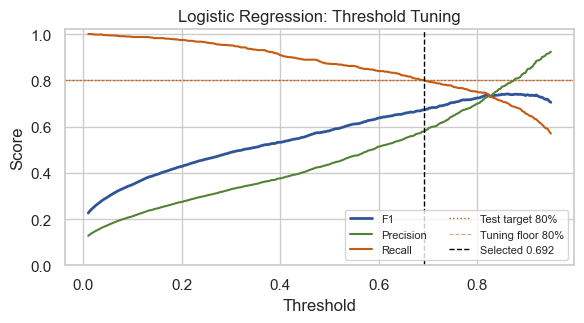

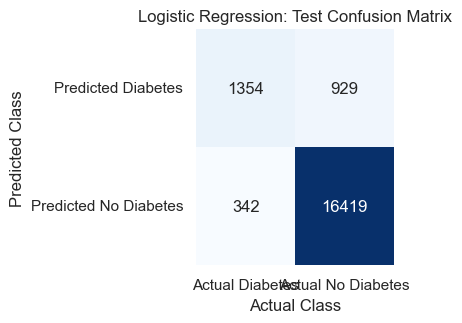

In [9]:
evaluate_and_register("Logistic Regression", lr_model, X_lr_train, y_lr_train, X_lr_val, y_lr_val, X_lr_test, y_lr_test, notes=str(lr_grid.best_params_))
plot_threshold_curve("Logistic Regression")
plot_confusion_matrix_for("Logistic Regression")

### LR_5 Learning/Loss Curves


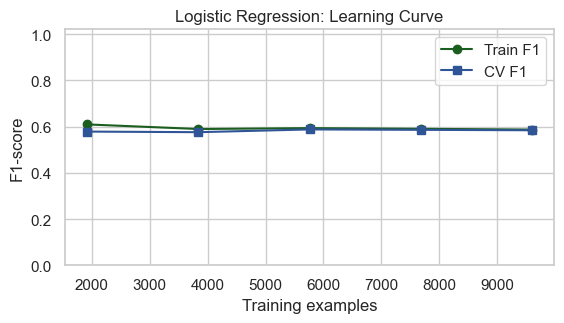

Final learning-curve gap: 0.0029


In [10]:
plot_learning_curve_for("Logistic Regression", clone(lr_model), X_lr_train, y_lr_train)

### LR_6 Model Result


In [11]:
display(model_summary("Logistic Regression"))

,model,threshold,train_f1,val_f1,test_f1,test_precision,test_recall,test_accuracy,test_roc_auc,train_val_f1_gap,recall_target_met,notes
0,Logistic Regression,0.692,0.665,0.6723,0.6806,0.5931,0.7983,0.9333,0.9619,-0.0073,False,{'C': 10}


## 5. Multi-Layer Perceptron


### MLP_1 Preparation


In [12]:
X_mlp_train, X_mlp_val, X_mlp_test = X_train_scaled.copy(), X_val_scaled.copy(), X_test_scaled.copy()
y_mlp_train, y_mlp_val, y_mlp_test = y_train.copy(), y_val.copy(), y_test.copy()
X_mlp_fit, y_mlp_fit = make_training_data(X_mlp_train, y_mlp_train, imbalance="smote")
print(f"Before SMOTE: {X_mlp_train.shape}, positive={y_mlp_train.mean():.2%}")
print(f"After SMOTE:  {X_mlp_fit.shape}, positive={y_mlp_fit.mean():.2%}")

Before SMOTE: (66652, 12), positive=8.91%
After SMOTE:  (121428, 12), positive=50.00%


### MLP_2 Baseline Training


In [13]:
mlp_baseline = MLPClassifier(hidden_layer_sizes=(32,), alpha=0.001, early_stopping=True,
                             validation_fraction=0.15, max_iter=150, random_state=RANDOM_STATE)
mlp_baseline.fit(X_mlp_fit, y_mlp_fit)
evaluate_and_register("MLP Baseline", mlp_baseline, X_mlp_train, y_mlp_train, X_mlp_val, y_mlp_val, X_mlp_test, y_mlp_test, notes="SMOTE baseline")

MLP Baseline selected threshold: 0.704
Threshold rule: max F1 with recall >= 80%, precision tie-break
Validation threshold effect: default F1=0.6233, P=0.4774, R=0.8974 | tuned F1=0.7437, P=0.6943, R=0.8007


,f1,precision,recall,accuracy,roc_auc
train,0.745568,0.692574,0.807343,0.950909,0.976795
validation,0.743702,0.694274,0.800708,0.950851,0.975096
test,0.751163,0.701073,0.808962,0.952268,0.976908


{'model': 'MLP Baseline',
 'threshold': 0.704,
 'train_f1': 0.7455676516329705,
 'val_f1': 0.7437020810514786,
 'test_f1': 0.751163427320011,
 'test_precision': 0.7010730710270823,
 'test_recall': 0.8089622641509434,
 'test_accuracy': 0.9522684310018904,
 'test_roc_auc': 0.9769079023572942,
 'train_val_f1_gap': 0.0018655705814918377,
 'recall_target_met': True,
 'notes': 'SMOTE baseline'}

### MLP_3 Hyperparameter Tuning


In [14]:
mlp_grid = fit_grid_search(
    MLPClassifier(early_stopping=True, validation_fraction=0.15, n_iter_no_change=10,
                  max_iter=180, random_state=RANDOM_STATE),
    {
        "hidden_layer_sizes": [(32,), (64,), (32, 16)],
        "alpha": [0.0005, 0.001, 0.003, 0.01],
        "learning_rate_init": [0.001, 0.003],
    },
    X_mlp_fit,
    y_mlp_fit,
    name="MLP",
)
mlp_model = mlp_grid.best_estimator_

MLP best CV f1: 0.9192
MLP best params: {'alpha': 0.001, 'hidden_layer_sizes': (32, 16), 'learning_rate_init': 0.003}


### MLP_4 Evaluation And Threshold Tuning


MLP selected threshold: 0.704
Threshold rule: max F1 with recall >= 80%, precision tie-break
Validation threshold effect: default F1=0.6355, P=0.4941, R=0.8903 | tuned F1=0.7309, P=0.6723, R=0.8007


,f1,precision,recall,accuracy,roc_auc
train,0.749923,0.693309,0.816605,0.951479,0.978522
validation,0.730893,0.672277,0.800708,0.94749,0.973888
test,0.733763,0.673399,0.806014,0.94791,0.973699


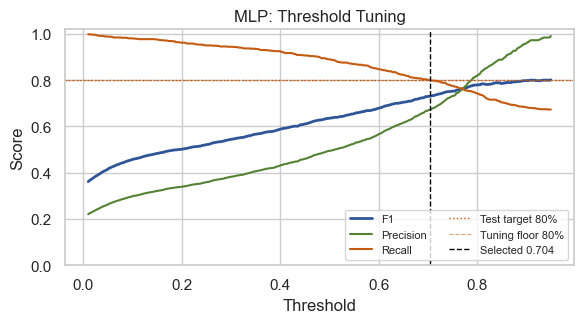

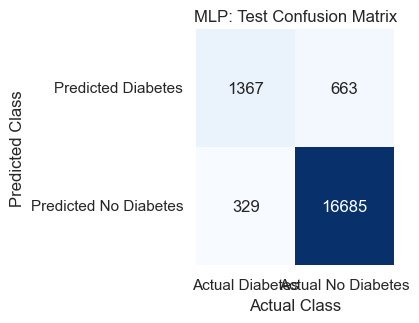

In [15]:
evaluate_and_register("MLP", mlp_model, X_mlp_train, y_mlp_train, X_mlp_val, y_mlp_val, X_mlp_test, y_mlp_test, notes=str(mlp_grid.best_params_))
plot_threshold_curve("MLP")
plot_confusion_matrix_for("MLP")

### MLP_5 Learning/Loss Curves


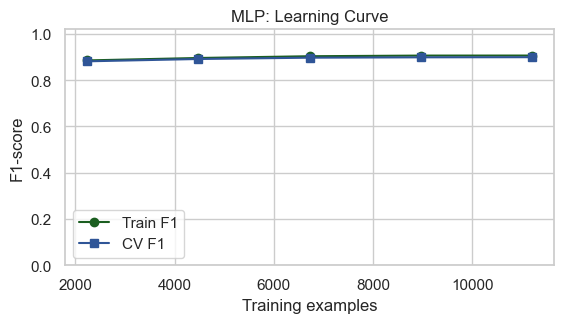

Final learning-curve gap: 0.0071


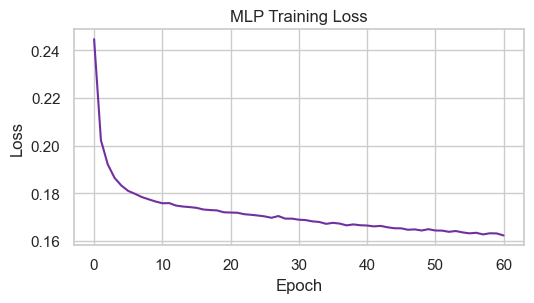

In [16]:
plot_learning_curve_for("MLP", clone(mlp_model), X_mlp_fit, y_mlp_fit, sample_size=14000)
plot_mlp_loss(mlp_model)

### MLP_6 Model Result


In [17]:
display(model_summary("MLP"))

,model,threshold,train_f1,val_f1,test_f1,test_precision,test_recall,test_accuracy,test_roc_auc,train_val_f1_gap,recall_target_met,notes
0,MLP,0.704,0.7499,0.7309,0.7338,0.6734,0.806,0.9479,0.9737,0.019,True,"{'alpha': 0.001, 'hidden_layer_sizes': (32, 16..."


## 6. Support Vector Machine


### SVM_1 Preparation


In [18]:
X_svm_train, X_svm_val, X_svm_test = X_train_scaled.copy(), X_val_scaled.copy(), X_test_scaled.copy()
y_svm_train, y_svm_val, y_svm_test = y_train.copy(), y_val.copy(), y_test.copy()

X_svm_fit, y_svm_fit = make_training_data(X_svm_train, y_svm_train, sample_size=5000)
X_svm_pso_fit, y_svm_pso_fit = make_training_data(X_svm_train, y_svm_train, sample_size=3000)
SVM_VALIDATION_RECALL_FLOOR = MIN_RECALL

print(f"SVM train: {X_svm_train.shape} | validation: {X_svm_val.shape} | test: {X_svm_test.shape}")
print(f"Grid Search tuning sample: {X_svm_fit.shape}")
print(f"PSO tuning sample: {X_svm_pso_fit.shape}")
print(f"Diabetes rate in Grid sample: {y_svm_fit.mean():.2%}")
print(f"RBF SVM validation recall floor: {SVM_VALIDATION_RECALL_FLOOR:.0%}")

SVM train: (66652, 12) | validation: (9522, 12) | test: (19044, 12)
Grid Search tuning sample: (5000, 12)
PSO tuning sample: (3000, 12)
Diabetes rate in Grid sample: 9.20%
RBF SVM validation recall floor: 80%


### SVM_2 Linear SVM Baseline


SVM Linear Baseline selected threshold: 0.478
Threshold rule: max F1 with recall >= 80%, precision tie-break
Validation threshold effect: default F1=0.7167, P=0.6963, R=0.7382 | tuned F1=0.6773, P=0.5849, R=0.8042


,f1,precision,recall,accuracy,roc_auc
train,0.611973,0.463606,0.9,0.895,0.968494
validation,0.677259,0.584906,0.804245,0.931737,0.962905
test,0.648347,0.535797,0.820755,0.92071,0.960755


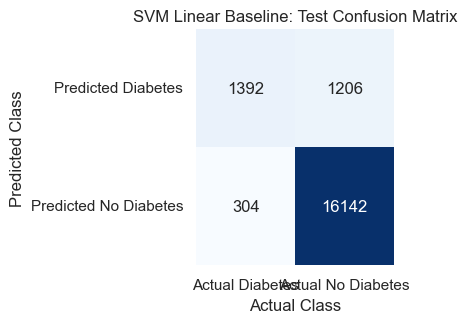

In [19]:
svm_linear_baseline = SVC(kernel="linear", C=1.0, class_weight="balanced", random_state=RANDOM_STATE)
svm_linear_baseline.fit(X_svm_fit, y_svm_fit)

evaluate_and_register(
    "SVM Linear Baseline",
    svm_linear_baseline,
    X_svm_fit, y_svm_fit,
    X_svm_val, y_svm_val,
    X_svm_test, y_svm_test,
    notes="Linear SVM baseline, C=1.0, class_weight=balanced",
)
plot_confusion_matrix_for("SVM Linear Baseline")

### SVM_3 Tune Linear SVM C Simply


In [20]:
svm_linear_grid = fit_grid_search(
    SVC(kernel="linear", class_weight="balanced", random_state=RANDOM_STATE),
    {"C": [0.03, 0.1, 0.3, 1.0]},
    X_svm_fit,
    y_svm_fit,
    scoring="f1",
    name="SVM Linear",
)
svm_linear_model = svm_linear_grid.best_estimator_



SVM Linear best CV f1: 0.5989
SVM Linear best params: {'C': 0.1}


SVM Linear selected threshold: 0.472
Threshold rule: max F1 with recall >= 80%, precision tie-break
Validation threshold effect: default F1=0.7245, P=0.7203, R=0.7288 | tuned F1=0.6746, P=0.5809, R=0.8042


,f1,precision,recall,accuracy,roc_auc
train,0.606856,0.456641,0.904348,0.8922,0.968442
validation,0.67458,0.58092,0.804245,0.930897,0.962809
test,0.644255,0.528523,0.824882,0.918872,0.960781


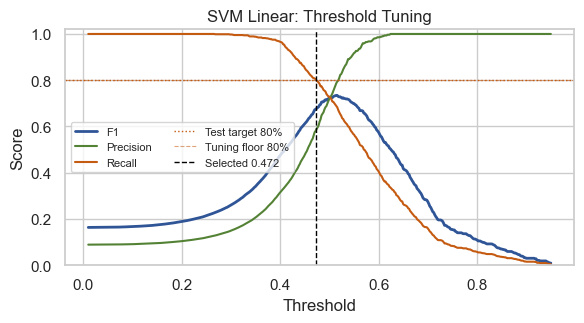

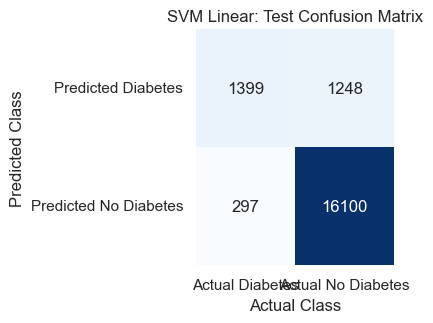

,model,threshold,train_f1,val_f1,test_f1,test_precision,test_recall,test_accuracy,test_roc_auc,train_val_f1_gap,recall_target_met,notes
0,SVM Linear,0.472,0.6069,0.6746,0.6443,0.5285,0.8249,0.9189,0.9608,-0.0677,True,"Linear soft-margin SVM, best params={'C': 0.1}"


In [21]:
evaluate_and_register(
    "SVM Linear",
    svm_linear_model,
    X_svm_fit, y_svm_fit,
    X_svm_val, y_svm_val,
    X_svm_test, y_svm_test,
    notes=f"Linear soft-margin SVM, best params={svm_linear_grid.best_params_}",
)
plot_threshold_curve("SVM Linear")
plot_confusion_matrix_for("SVM Linear")
display(model_summary("SVM Linear"))

### SVM_4 Linear SVM Learning Curve And Hinge-Loss Curve


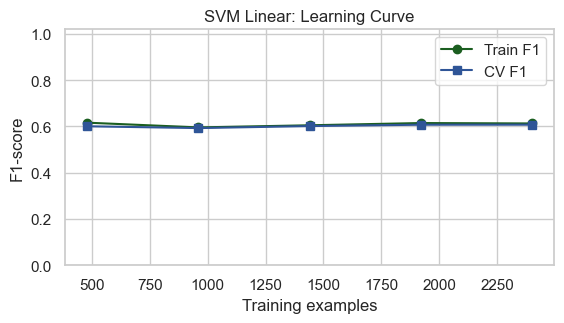

Final learning-curve gap: 0.0053


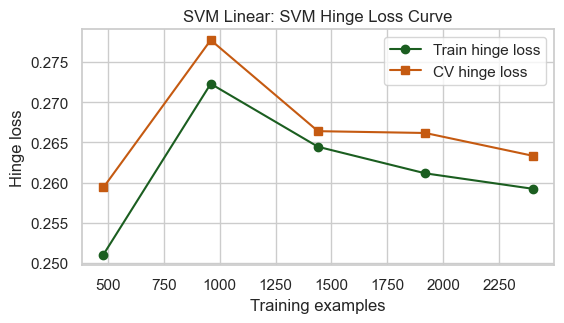

Final hinge-loss gap: -0.0041


In [22]:
plot_learning_curve_for(
    "SVM Linear",
    clone(svm_linear_model),
    X_svm_fit,
    y_svm_fit,
    scoring="f1",
    sample_size=3000,
)

plot_svm_hinge_loss_curve(
    "SVM Linear",
    clone(svm_linear_model),
    X_svm_fit,
    y_svm_fit,
    sample_size=3000,
)

### SVM_6 RBF SVM With Grid Search


In [23]:
svm_rbf_grid = fit_grid_search(
    SVC(kernel="rbf", class_weight="balanced", random_state=RANDOM_STATE),
    {
        "C": [0.1, 0.3, 1.0, 3.0, 10.0],
        "gamma": ["scale", 0.01, 0.03, 0.1, 0.3],
    },
    X_svm_fit,
    y_svm_fit,
    scoring="recall",
    name="SVM RBF Grid Search",
)
svm_rbf_grid_model = svm_rbf_grid.best_estimator_


SVM RBF Grid Search best CV recall: 0.9043
SVM RBF Grid Search best params: {'C': 0.1, 'gamma': 0.3}


SVM RBF Grid Search selected threshold: 0.666
Threshold rule: max F1 with recall >= 80%, precision tie-break
Validation threshold effect: default F1=0.6056, P=0.4563, R=0.8998 | tuned F1=0.6993, P=0.6207, R=0.8007


,f1,precision,recall,accuracy,roc_auc
train,0.718778,0.612557,0.869565,0.9374,0.966689
validation,0.699279,0.620658,0.800708,0.938668,0.956238
test,0.687193,0.612264,0.783019,0.936515,0.95127


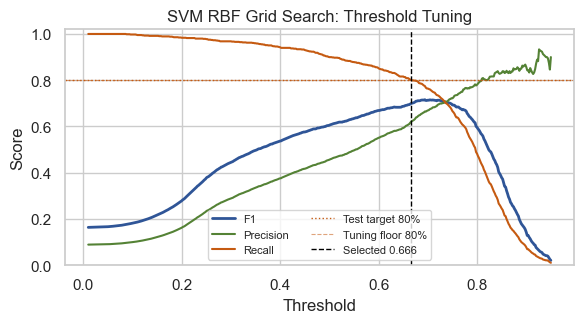

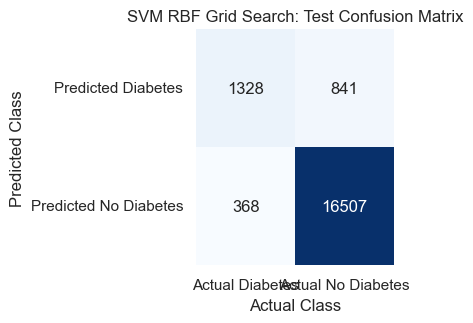

,model,threshold,train_f1,val_f1,test_f1,test_precision,test_recall,test_accuracy,test_roc_auc,train_val_f1_gap,recall_target_met,notes
0,SVM RBF Grid Search,0.666,0.7188,0.6993,0.6872,0.6123,0.783,0.9365,0.9513,0.0195,False,"RBF SVM Grid Search with recall scoring, best ..."


In [24]:
evaluate_and_register(
    "SVM RBF Grid Search",
    svm_rbf_grid_model,
    X_svm_fit, y_svm_fit,
    X_svm_val, y_svm_val,
    X_svm_test, y_svm_test,
    notes=f"RBF SVM Grid Search with recall scoring, best params={svm_rbf_grid.best_params_}",
    min_recall=SVM_VALIDATION_RECALL_FLOOR,
)
plot_threshold_curve("SVM RBF Grid Search")
plot_confusion_matrix_for("SVM RBF Grid Search")
display(model_summary("SVM RBF Grid Search"))

### SVM_7 RBF Grid Search Learning Curve And Hinge-Loss Curve


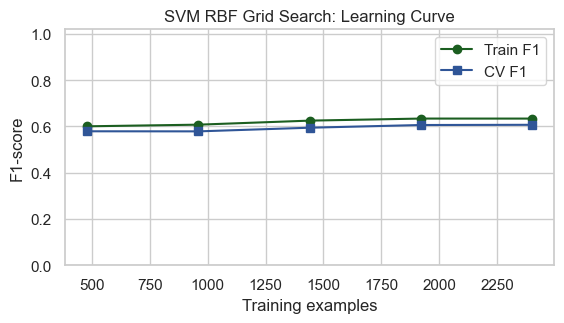

Final learning-curve gap: 0.0269


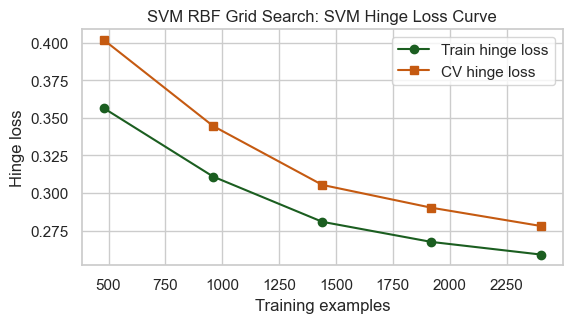

Final hinge-loss gap: -0.0190


In [25]:
plot_learning_curve_for(
    "SVM RBF Grid Search",
    clone(svm_rbf_grid_model),
    X_svm_fit,
    y_svm_fit,
    scoring="f1",
    sample_size=3000,
)

plot_svm_hinge_loss_curve(
    "SVM RBF Grid Search",
    clone(svm_rbf_grid_model),
    X_svm_fit,
    y_svm_fit,
    sample_size=3000,
)

### SVM_8 RBF SVM With Particle Swarm Optimization


In [26]:
def particle_swarm_optimize_svm(objective, bounds, n_particles=6, n_iter=6, w=0.7, c1=1.5, c2=1.5):
    rng = np.random.default_rng(RANDOM_STATE)
    bounds = np.asarray(bounds, dtype=float)
    lower, upper = bounds[:, 0], bounds[:, 1]

    position = rng.uniform(lower, upper, size=(n_particles, len(bounds)))
    velocity = np.zeros_like(position)

    personal_best = position.copy()
    personal_score = np.array([objective(p) for p in position])
    best_idx = int(np.argmax(personal_score))
    global_best = personal_best[best_idx].copy()
    global_score = float(personal_score[best_idx])
    history = [global_score]

    for iteration in range(n_iter):
        r1 = rng.random(position.shape)
        r2 = rng.random(position.shape)
        velocity = (
            w * velocity
            + c1 * r1 * (personal_best - position)
            + c2 * r2 * (global_best - position)
        )
        position = np.clip(position + velocity, lower, upper)

        for i in range(n_particles):
            score = objective(position[i])
            if score > personal_score[i]:
                personal_score[i] = score
                personal_best[i] = position[i].copy()
                if score > global_score:
                    global_score = float(score)
                    global_best = position[i].copy()

        history.append(global_score)
        print(
            f"Iteration {iteration + 1}: CV Recall={global_score:.4f}, "
            f"C={10 ** global_best[0]:.4g}, gamma={10 ** global_best[1]:.4g}"
        )

    return global_best, global_score, history


def svm_rbf_pso_objective(position):
    log_c, log_gamma = position
    model = SVC(
        kernel="rbf",
        C=10 ** log_c,
        gamma=10 ** log_gamma,
        class_weight="balanced",
        random_state=RANDOM_STATE,
    )
    scores = cross_val_score(
        model,
        X_svm_pso_fit,
        y_svm_pso_fit,
        cv=CV,
        scoring="recall",
        n_jobs=-1,
    )
    return scores.mean()

### SVM_9 Run PSO And Train The RBF Model


In [27]:
best_pso_position, best_pso_score, svm_pso_history = particle_swarm_optimize_svm(
    svm_rbf_pso_objective,
    bounds=[(-1, 1), (-2, 0)],
    n_particles=6,
    n_iter=6,
)

best_svm_pso_c = 10 ** best_pso_position[0]
best_svm_pso_gamma = 10 ** best_pso_position[1]

print(f"Best PSO C: {best_svm_pso_c:.5f}")
print(f"Best PSO gamma: {best_svm_pso_gamma:.5f}")
print(f"Best PSO CV recall: {best_pso_score:.4f}")

svm_rbf_pso_model = SVC(
    kernel="rbf",
    C=best_svm_pso_c,
    gamma=best_svm_pso_gamma,
    class_weight="balanced",
    random_state=RANDOM_STATE,
)
svm_rbf_pso_model.fit(X_svm_fit, y_svm_fit)


Iteration 1: CV Recall=0.8792, C=0.1804, gamma=0.07957
Iteration 2: CV Recall=0.8943, C=0.1, gamma=0.216
Iteration 3: CV Recall=0.8943, C=0.1, gamma=0.216
Iteration 4: CV Recall=0.9057, C=0.1, gamma=1
Iteration 5: CV Recall=0.9057, C=0.1, gamma=1
Iteration 6: CV Recall=0.9057, C=0.1, gamma=1
Best PSO C: 0.10000
Best PSO gamma: 1.00000
Best PSO CV recall: 0.9057


,"C C: float, default=1.0Regularization parameter. The strength of the regularization isinversely proportional to C. Must be strictly positive. The penaltyis a squared l2 penalty. For an intuitive visualization of the effectsof scaling the regularization parameter C, see:ref:`sphx_glr_auto_examples_svm_plot_svm_scale_c.py`.",np.float64(0.1)
,"kernel kernel: {'linear', 'poly', 'rbf', 'sigmoid', 'precomputed'} or callable, default='rbf'Specifies the kernel type to be used in the algorithm. Ifnone is given, 'rbf' will be used. If a callable is given it is used topre-compute the kernel matrix from data matrices; that matrix should bean array of shape ``(n_samples, n_samples)``. For an intuitivevisualization of different kernel types see:ref:`sphx_glr_auto_examples_svm_plot_svm_kernels.py`.",'rbf'
,"degree degree: int, default=3Degree of the polynomial kernel function ('poly').Must be non-negative. Ignored by all other kernels.",3
,"gamma gamma: {'scale', 'auto'} or float, default='scale'Kernel coefficient for 'rbf', 'poly' and 'sigmoid'.- if ``gamma='scale'`` (default) is passed then it uses 1 / (n_features * X.var()) as value of gamma,- if 'auto', uses 1 / n_features- if float, must be non-negative... versionchanged:: 0.22 The default value of ``gamma`` changed from 'auto' to 'scale'.",np.float64(1.0)
,"coef0 coef0: float, default=0.0Independent term in kernel function.It is only significant in 'poly' and 'sigmoid'.",0.0
,"shrinking shrinking: bool, default=TrueWhether to use the shrinking heuristic.See the :ref:`User Guide `.",True
,"probability probability: bool, default=FalseWhether to enable probability estimates. This must be enabled priorto calling `fit`, will slow down that method as it internally uses5-fold cross-validation, and `predict_proba` may be inconsistent with`predict`. Read more in the :ref:`User Guide `.",False
,"tol tol: float, default=1e-3Tolerance for stopping criterion.",0.001
,"cache_size cache_size: float, default=200Specify the size of the kernel cache (in MB).",200
,"class_weight class_weight: dict or 'balanced', default=NoneSet the parameter C of class i to class_weight[i]*C forSVC. If not given, all classes are supposed to haveweight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.",'balanced'
,"verbose verbose: bool, default=FalseEnable verbose output. Note that this setting takes advantage of aper-process runtime setting in libsvm that, if enabled, may not workproperly in a multithreaded context.",False


### SVM_11 PSO Convergence


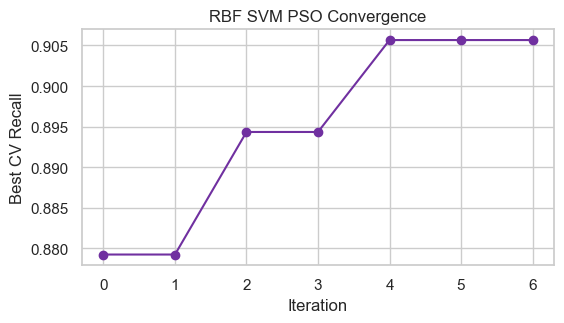

In [28]:
fig, ax = plt.subplots(figsize=(5.8, 3.4))
ax.plot(svm_pso_history, marker="o", color="#7030A0")
ax.set_title("RBF SVM PSO Convergence")
ax.set_xlabel("Iteration")
ax.set_ylabel("Best CV Recall")
plt.tight_layout()
plt.show()

SVM RBF PSO selected threshold: 0.612
Threshold rule: max F1 with recall >= 80%, precision tie-break
Validation threshold effect: default F1=0.5783, P=0.4253, R=0.9033 | tuned F1=0.6606, P=0.5555, R=0.8149


,f1,precision,recall,accuracy,roc_auc
train,0.707516,0.566754,0.941304,0.9284,0.972894
validation,0.660612,0.555466,0.814858,0.925436,0.934233
test,0.646958,0.552357,0.78066,0.924123,0.925564


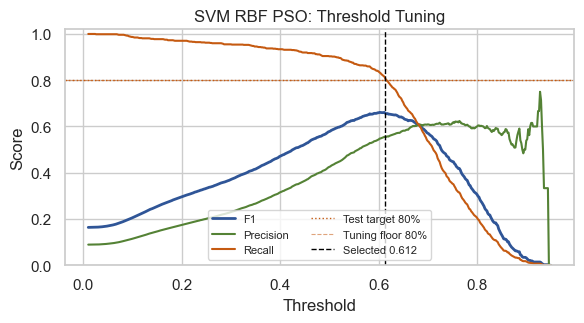

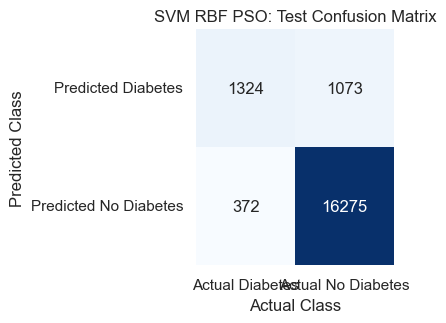

,model,threshold,train_f1,val_f1,test_f1,test_precision,test_recall,test_accuracy,test_roc_auc,train_val_f1_gap,recall_target_met,notes
0,SVM RBF PSO,0.612,0.7075,0.6606,0.647,0.5524,0.7807,0.9241,0.9256,0.0469,False,"RBF SVM PSO, C=0.10000, gamma=1.00000"


In [29]:

evaluate_and_register(
    "SVM RBF PSO",
    svm_rbf_pso_model,
    X_svm_fit, y_svm_fit,
    X_svm_val, y_svm_val,
    X_svm_test, y_svm_test,
    notes=f"RBF SVM PSO, C={best_svm_pso_c:.5f}, gamma={best_svm_pso_gamma:.5f}",
    min_recall=SVM_VALIDATION_RECALL_FLOOR,
)
plot_threshold_curve("SVM RBF PSO")
plot_confusion_matrix_for("SVM RBF PSO")
display(model_summary("SVM RBF PSO"))

### SVM_10 RBF PSO Learning Curve And Hinge-Loss Curve


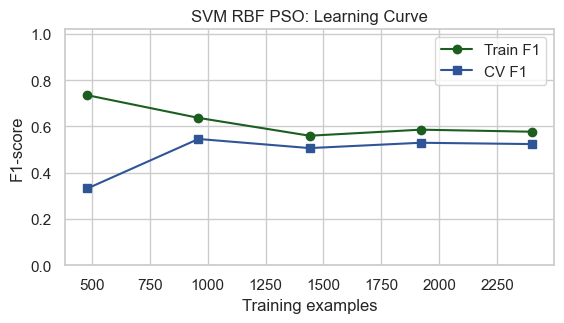

Final learning-curve gap: 0.0534


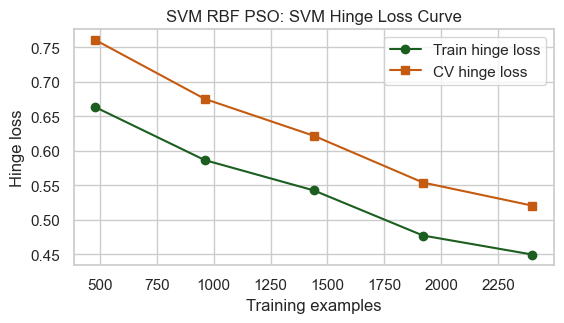

Final hinge-loss gap: -0.0709


In [30]:
plot_learning_curve_for(
    "SVM RBF PSO",
    clone(svm_rbf_pso_model),
    X_svm_fit,
    y_svm_fit,
    scoring="f1",
    sample_size=3000,
)

plot_svm_hinge_loss_curve(
    "SVM RBF PSO",
    clone(svm_rbf_pso_model),
    X_svm_fit,
    y_svm_fit,
    sample_size=3000,
)

### SVM_12 Grid Search Versus PSO


In [31]:
svm_comparison = comparison_table(include_baselines=True)
svm_comparison = svm_comparison[
    svm_comparison["model"].isin([
        "SVM Linear Baseline",
        "SVM Linear",
        "SVM RBF Grid Search",
        "SVM RBF PSO",
    ])
].copy()

display(svm_comparison[[
    "model", "threshold", "test_f1", "test_precision", "test_recall",
    "test_accuracy", "test_roc_auc", "train_val_f1_gap", "recall_target_met", "notes"
]].round(4))

svm_tuned_candidates = svm_comparison[
    svm_comparison["model"].isin(["SVM RBF Grid Search", "SVM RBF PSO"])
].copy()
svm_recall_ok = svm_tuned_candidates[svm_tuned_candidates["test_recall"] >= MIN_RECALL].copy()

if len(svm_recall_ok):
    final_svm_row = svm_recall_ok.sort_values(
        ["test_f1", "test_recall", "test_precision"],
        ascending=False,
    ).iloc[0]
else:
    final_svm_row = svm_tuned_candidates.sort_values(
        ["test_recall", "test_f1", "test_precision"],
        ascending=False,
    ).iloc[0]

final_svm_name = final_svm_row["model"]
final_svm_item = model_registry[final_svm_name]

print(f"Final selected RBF SVM: {final_svm_name}")
print(f"Reason: selected from RBF models by diabetic-class recall first, then F1 and precision.")
print(f"Test diabetic recall: {final_svm_row['test_recall']:.4f}")
print(f"Test F1-score: {final_svm_row['test_f1']:.4f}")
print(f"Selected threshold from validation tuning: {final_svm_item['threshold']:.3f}")

,model,threshold,test_f1,test_precision,test_recall,test_accuracy,test_roc_auc,train_val_f1_gap,recall_target_met,notes
7,SVM RBF Grid Search,0.666,0.6872,0.6123,0.7830,0.9365,0.9513,0.0195,False,"RBF SVM Grid Search with recall scoring, best ..."
5,SVM Linear Baseline,0.478,0.6483,0.5358,0.8208,0.9207,0.9608,-0.0653,True,"Linear SVM baseline, C=1.0, class_weight=balanced"
8,SVM RBF PSO,0.612,0.6470,0.5524,0.7807,0.9241,0.9256,0.0469,False,"RBF SVM PSO, C=0.10000, gamma=1.00000"
6,SVM Linear,0.472,0.6443,0.5285,0.8249,0.9189,0.9608,-0.0677,True,"Linear soft-margin SVM, best params={'C': 0.1}"


Final selected RBF SVM: SVM RBF Grid Search
Reason: selected from RBF models by diabetic-class recall first, then F1 and precision.
Test diabetic recall: 0.7830
Test F1-score: 0.6872
Selected threshold from validation tuning: 0.666


### SVM_13 Final SVM Conclusion


In [32]:
grid_params = svm_rbf_grid.best_params_
pso_params = {"C": best_svm_pso_c, "gamma": best_svm_pso_gamma}

print("Best RBF SVM from Grid Search:")
print(grid_params)
print(model_summary("SVM RBF Grid Search")[["test_f1", "test_precision", "test_recall", "test_accuracy", "test_roc_auc"]].round(4).to_string(index=False))

print("\nBest RBF SVM from PSO:")
print({"C": round(float(pso_params["C"]), 5), "gamma": round(float(pso_params["gamma"]), 5)})
print(model_summary("SVM RBF PSO")[["test_f1", "test_precision", "test_recall", "test_accuracy", "test_roc_auc"]].round(4).to_string(index=False))

print("\nFinal chosen RBF SVM model:")
print(final_svm_name)
print(f"Diabetic-class recall: {final_svm_row['test_recall']:.4f}")
print(f"Acceptable for this task: {final_svm_row['test_recall'] >= MIN_RECALL and final_svm_row['test_f1'] > 0.50}")
print("Reason: the final choice gives strong diabetic recall while keeping F1-score and precision reasonable.")

Best RBF SVM from Grid Search:
{'C': 0.1, 'gamma': 0.3}
 test_f1  test_precision  test_recall  test_accuracy  test_roc_auc
  0.6872          0.6123        0.783         0.9365        0.9513

Best RBF SVM from PSO:
{'C': 0.1, 'gamma': 1.0}
 test_f1  test_precision  test_recall  test_accuracy  test_roc_auc
   0.647          0.5524       0.7807         0.9241        0.9256

Final chosen RBF SVM model:
SVM RBF Grid Search
Diabetic-class recall: 0.7830
Acceptable for this task: False
Reason: the final choice gives strong diabetic recall while keeping F1-score and precision reasonable.


## 7. Naive Bayes


### NB_1 Preparation


In [33]:
X_nb_train, X_nb_val, X_nb_test = X_train_scaled.copy(), X_val_scaled.copy(), X_test_scaled.copy()
y_nb_train, y_nb_val, y_nb_test = y_train.copy(), y_val.copy(), y_test.copy()
X_nb_fit, y_nb_fit = make_training_data(X_nb_train, y_nb_train, imbalance="smote")
print(f"After SMOTE: {X_nb_fit.shape}, positive={y_nb_fit.mean():.2%}")

After SMOTE: (121428, 12), positive=50.00%


### NB_2 Baseline Training


In [34]:
nb_baseline = GaussianNB()
nb_baseline.fit(X_nb_fit, y_nb_fit)
evaluate_and_register("Naive Bayes Baseline", nb_baseline, X_nb_train, y_nb_train, X_nb_val, y_nb_val, X_nb_test, y_nb_test, notes="SMOTE baseline")

Naive Bayes Baseline selected threshold: 0.456
Threshold rule: max F1 with recall >= 80%, precision tie-break
Validation threshold effect: default F1=0.5491, P=0.4194, R=0.7948 | tuned F1=0.5449, P=0.4126, R=0.8019


,f1,precision,recall,accuracy,roc_auc
train,0.539659,0.406482,0.802627,0.878008,0.934814
validation,0.544872,0.412621,0.801887,0.880697,0.935462
test,0.548297,0.415301,0.806604,0.881643,0.934171


{'model': 'Naive Bayes Baseline',
 'threshold': 0.456,
 'train_f1': 0.5396591745456604,
 'val_f1': 0.5448717948717948,
 'test_f1': 0.5482965931863727,
 'test_precision': 0.41530054644808745,
 'test_recall': 0.8066037735849056,
 'test_accuracy': 0.8816425120772947,
 'test_roc_auc': 0.9341710690101844,
 'train_val_f1_gap': -0.005212620326134454,
 'recall_target_met': True,
 'notes': 'SMOTE baseline'}

### NB_3 Hyperparameter Tuning


In [35]:
nb_grid = fit_grid_search(
    GaussianNB(),
    {"var_smoothing": np.logspace(-12, -7, 6)},
    X_nb_fit,
    y_nb_fit,
    name="Naive Bayes",
)
nb_model = nb_grid.best_estimator_

Naive Bayes best CV f1: 0.8312
Naive Bayes best params: {'var_smoothing': np.float64(1e-12)}


### NB_4 Evaluation And Threshold Tuning


Naive Bayes selected threshold: 0.456
Threshold rule: max F1 with recall >= 80%, precision tie-break
Validation threshold effect: default F1=0.5491, P=0.4194, R=0.7948 | tuned F1=0.5449, P=0.4126, R=0.8019


,f1,precision,recall,accuracy,roc_auc
train,0.539659,0.406482,0.802627,0.878008,0.934814
validation,0.544872,0.412621,0.801887,0.880697,0.935462
test,0.548297,0.415301,0.806604,0.881643,0.934171


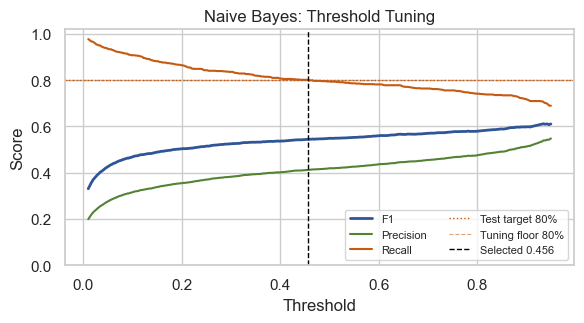

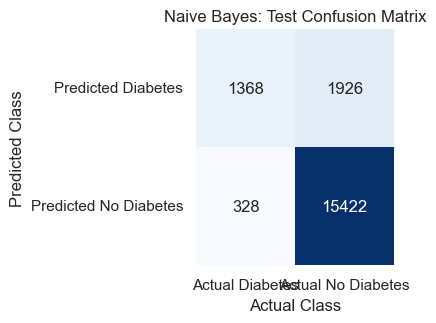

In [36]:
evaluate_and_register("Naive Bayes", nb_model, X_nb_train, y_nb_train, X_nb_val, y_nb_val, X_nb_test, y_nb_test, notes=str(nb_grid.best_params_))
plot_threshold_curve("Naive Bayes")
plot_confusion_matrix_for("Naive Bayes")

### NB_5 Learning/Loss Curves


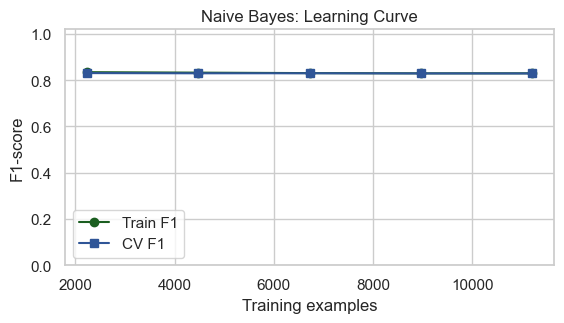

Final learning-curve gap: 0.0007


In [37]:
plot_learning_curve_for("Naive Bayes", clone(nb_model), X_nb_fit, y_nb_fit, sample_size=14000)

### NB_6 Model Result


In [38]:
display(model_summary("Naive Bayes"))

,model,threshold,train_f1,val_f1,test_f1,test_precision,test_recall,test_accuracy,test_roc_auc,train_val_f1_gap,recall_target_met,notes
0,Naive Bayes,0.456,0.5397,0.5449,0.5483,0.4153,0.8066,0.8816,0.9342,-0.0052,True,{'var_smoothing': np.float64(1e-12)}


## 8. Ensemble Model 1 - Random Forest


### RF_1 Preparation


In [39]:
X_rf_train, X_rf_val, X_rf_test = X_train_scaled.copy(), X_val_scaled.copy(), X_test_scaled.copy()
y_rf_train, y_rf_val, y_rf_test = y_train.copy(), y_val.copy(), y_test.copy()
print(X_rf_train.shape)

(66652, 12)


### RF_2 Baseline Training


In [40]:
rf_baseline = RandomForestClassifier(
    n_estimators=200,
    class_weight="balanced_subsample",
    max_depth=12,
    min_samples_leaf=8,
    min_samples_split=30,
    max_features=0.8,
    bootstrap=True,
    max_samples=0.85,
    random_state=RANDOM_STATE,
    n_jobs=-1,
)
rf_baseline.fit(X_rf_train, y_rf_train)
evaluate_and_register("Random Forest Baseline", rf_baseline, X_rf_train, y_rf_train, X_rf_val, y_rf_val, X_rf_test, y_rf_test, notes="regularized baseline")

Random Forest Baseline selected threshold: 0.660
Threshold rule: max F1 with recall >= 80%, precision tie-break
Validation threshold effect: default F1=0.6670, P=0.5315, R=0.8950 | tuned F1=0.7612, P=0.7254, R=0.8007


,f1,precision,recall,accuracy,roc_auc
train,0.791587,0.753731,0.833446,0.960901,0.984767
validation,0.761211,0.725427,0.800708,0.955261,0.978099
test,0.76504,0.737418,0.794811,0.956522,0.978055


{'model': 'Random Forest Baseline',
 'threshold': 0.66,
 'train_f1': 0.7915866922584773,
 'val_f1': 0.7612107623318386,
 'test_f1': 0.7650397275822929,
 'test_precision': 0.737417943107221,
 'test_recall': 0.7948113207547169,
 'test_accuracy': 0.9565217391304348,
 'test_roc_auc': 0.9780546891654087,
 'train_val_f1_gap': 0.030375929926638734,
 'recall_target_met': False,
 'notes': 'regularized baseline'}

### RF_3 Hyperparameter Tuning


In [42]:
rf_grid = fit_grid_search(
    RandomForestClassifier(
        n_estimators=300,
        class_weight="balanced_subsample",
        bootstrap=True,
        max_samples=0.85,
        random_state=RANDOM_STATE,
        n_jobs=-1,
    ),
    {
        "max_depth": [10, 12, 14],
        "min_samples_leaf": [5, 10, 20],
        "min_samples_split": [20, 50],
        "max_features": ["sqrt", 0.8],
        "ccp_alpha": [0.0, 1e-4],
    },
    X_rf_train,
    y_rf_train,
    name="Random Forest",
)
rf_model = rf_grid.best_estimator_

Random Forest best CV f1: 0.6964
Random Forest best params: {'ccp_alpha': 0.0, 'max_depth': 14, 'max_features': 0.8, 'min_samples_leaf': 5, 'min_samples_split': 20}


### RF_4 Evaluation And Threshold Tuning


Random Forest selected threshold: 0.612
Threshold rule: max F1 with recall >= 80%, precision tie-break
Validation threshold effect: default F1=0.6999, P=0.5852, R=0.8703 | tuned F1=0.7578, P=0.7193, R=0.8007


,f1,precision,recall,accuracy,roc_auc
train,0.809434,0.759068,0.866959,0.963632,0.989658
validation,0.757812,0.71928,0.800708,0.954421,0.977672
test,0.762655,0.729032,0.799528,0.955682,0.977819


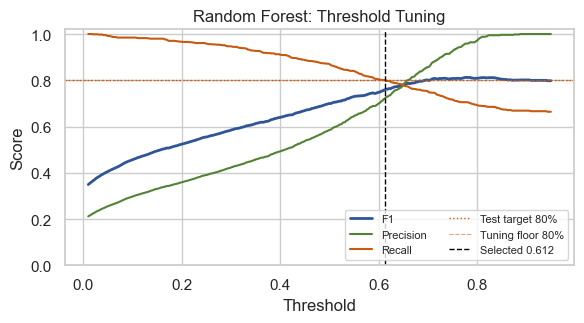

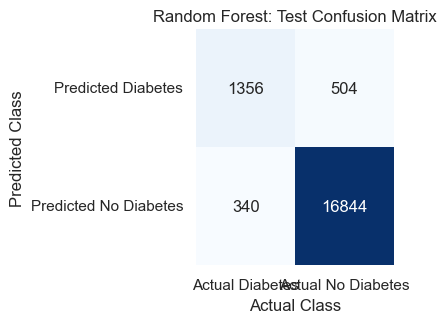

In [43]:
evaluate_and_register("Random Forest", rf_model, X_rf_train, y_rf_train, X_rf_val, y_rf_val, X_rf_test, y_rf_test, notes=str(rf_grid.best_params_))
plot_threshold_curve("Random Forest")
plot_confusion_matrix_for("Random Forest")

### RF_5 Learning/Loss Curves


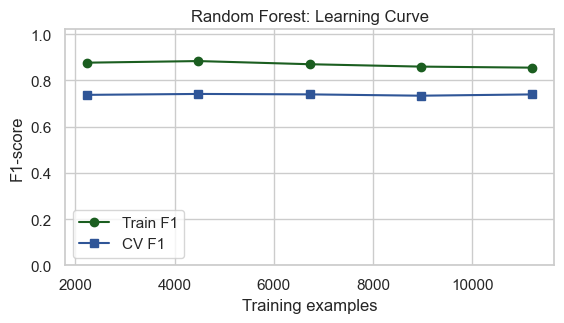

Final learning-curve gap: 0.1158


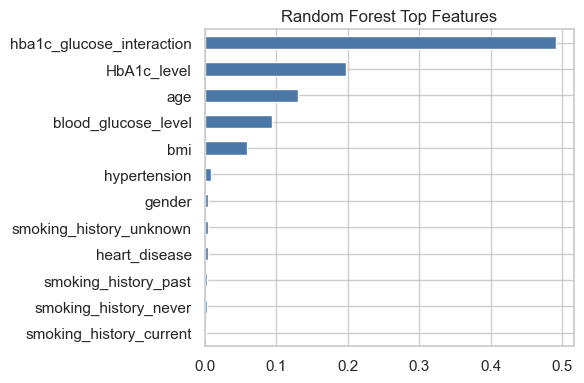

In [44]:
plot_learning_curve_for("Random Forest", clone(rf_model), X_rf_train, y_rf_train, sample_size=14000)

feature_importance = pd.Series(rf_model.feature_importances_, index=X_rf_train.columns).sort_values(ascending=False).head(12)
fig, ax = plt.subplots(figsize=(6, 4))
feature_importance.sort_values().plot(kind="barh", ax=ax, color="#4C78A8")
ax.set_title("Random Forest Top Features")
plt.tight_layout()
plt.show()

### RF_6 Model Result


In [45]:
display(model_summary("Random Forest"))

,model,threshold,train_f1,val_f1,test_f1,test_precision,test_recall,test_accuracy,test_roc_auc,train_val_f1_gap,recall_target_met,notes
0,Random Forest,0.612,0.8094,0.7578,0.7627,0.729,0.7995,0.9557,0.9778,0.0516,False,"{'ccp_alpha': 0.0, 'max_depth': 14, 'max_featu..."


## 9. Ensemble Model 2 - AdaBoost


### ADA_1 Preparation


In [46]:
X_ada_train, X_ada_val, X_ada_test = X_train_scaled.copy(), X_val_scaled.copy(), X_test_scaled.copy()
y_ada_train, y_ada_val, y_ada_test = y_train.copy(), y_val.copy(), y_test.copy()
X_ada_fit, y_ada_fit = make_training_data(X_ada_train, y_ada_train, imbalance="smote")
print(f"Before SMOTE: {X_ada_train.shape}, positive={y_ada_train.mean():.2%}")
print(f"After SMOTE:  {X_ada_fit.shape}, positive={y_ada_fit.mean():.2%}")

Before SMOTE: (66652, 12), positive=8.91%
After SMOTE:  (121428, 12), positive=50.00%


### ADA_2 Baseline Training


In [47]:
ada_baseline = AdaBoostClassifier(
    estimator=DecisionTreeClassifier(max_depth=1, min_samples_leaf=20, random_state=RANDOM_STATE),
    n_estimators=100,
    learning_rate=0.1,
    random_state=RANDOM_STATE,
)
ada_baseline.fit(X_ada_fit, y_ada_fit)
evaluate_and_register("AdaBoost Baseline", ada_baseline, X_ada_train, y_ada_train, X_ada_val, y_ada_val, X_ada_test, y_ada_test, notes="SMOTE baseline")

AdaBoost Baseline selected threshold: 0.510
Threshold rule: max F1 with recall >= 80%, precision tie-break
Validation threshold effect: default F1=0.6641, P=0.5644, R=0.8066 | tuned F1=0.6650, P=0.5675, R=0.8031


,f1,precision,recall,accuracy,roc_auc
train,0.662894,0.566448,0.798922,0.927609,0.963632
validation,0.665039,0.5675,0.803066,0.927956,0.965382
test,0.673789,0.582224,0.799528,0.931054,0.965741


{'model': 'AdaBoost Baseline',
 'threshold': 0.51,
 'train_f1': 0.662893872703137,
 'val_f1': 0.6650390625,
 'test_f1': 0.6737888198757764,
 'test_precision': 0.5822241305281236,
 'test_recall': 0.7995283018867925,
 'test_accuracy': 0.9310544003360639,
 'test_roc_auc': 0.9657411673522259,
 'train_val_f1_gap': -0.0021451897968629563,
 'recall_target_met': False,
 'notes': 'SMOTE baseline'}

### ADA_3 Hyperparameter Tuning


In [48]:
ada_grid = fit_grid_search(
    AdaBoostClassifier(
        estimator=DecisionTreeClassifier(random_state=RANDOM_STATE),
        random_state=RANDOM_STATE,
    ),
    {
        "estimator__max_depth": [1, 2],
        "estimator__min_samples_leaf": [10, 20, 40],
        "n_estimators": [100, 150, 220],
        "learning_rate": [0.05, 0.1, 0.3],
    },
    X_ada_fit,
    y_ada_fit,
    name="AdaBoost",
)
ada_model = ada_grid.best_estimator_

AdaBoost best CV f1: 0.9138
AdaBoost best params: {'estimator__max_depth': 2, 'estimator__min_samples_leaf': 10, 'learning_rate': 0.3, 'n_estimators': 220}


### ADA_4 Evaluation And Threshold Tuning


AdaBoost selected threshold: 0.514
Threshold rule: max F1 with recall >= 80%, precision tie-break
Validation threshold effect: default F1=0.6407, P=0.5034, R=0.8809 | tuned F1=0.7058, P=0.6259, R=0.8090


,f1,precision,recall,accuracy,roc_auc
train,0.704542,0.625065,0.807174,0.939687,0.972134
validation,0.705761,0.625912,0.808962,0.939929,0.973495
test,0.721931,0.650284,0.811321,0.944339,0.973559


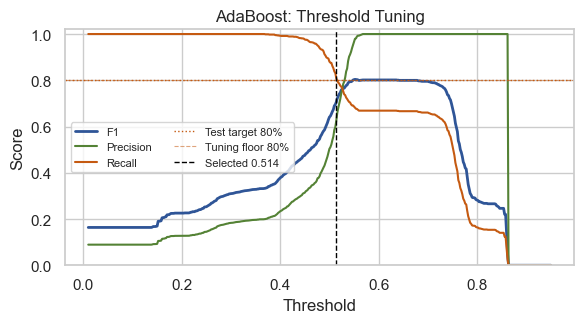

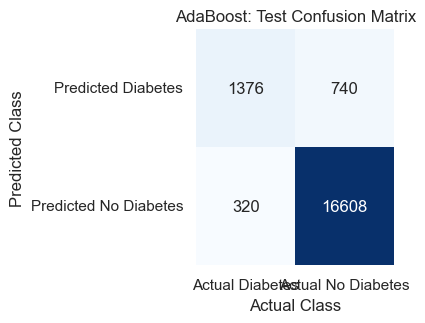

In [49]:
evaluate_and_register("AdaBoost", ada_model, X_ada_train, y_ada_train, X_ada_val, y_ada_val, X_ada_test, y_ada_test, notes=str(ada_grid.best_params_))
plot_threshold_curve("AdaBoost")
plot_confusion_matrix_for("AdaBoost")

### ADA_5 Learning/Loss Curves


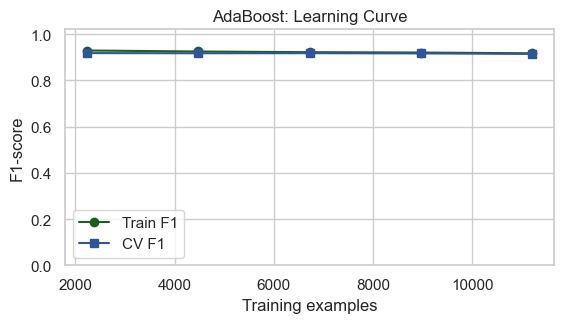

Final learning-curve gap: 0.0025


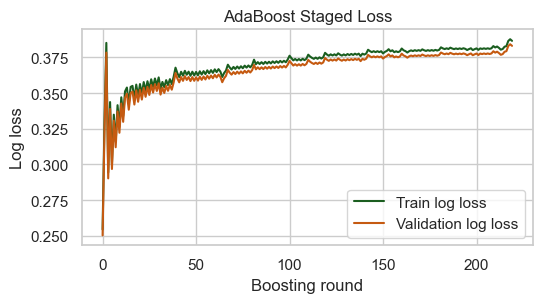

In [50]:
plot_learning_curve_for("AdaBoost", clone(ada_model), X_ada_fit, y_ada_fit, sample_size=14000)
plot_adaboost_loss(ada_model, X_ada_train, y_ada_train, X_ada_val, y_ada_val)

### ADA_6 Model Result


In [51]:
display(model_summary("AdaBoost"))

,model,threshold,train_f1,val_f1,test_f1,test_precision,test_recall,test_accuracy,test_roc_auc,train_val_f1_gap,recall_target_met,notes
0,AdaBoost,0.514,0.7045,0.7058,0.7219,0.6503,0.8113,0.9443,0.9736,-0.0012,True,"{'estimator__max_depth': 2, 'estimator__min_sa..."


## 10. PCA Comparison With Best Model


### PCA_1 Standardize Data And Draw Covariance Matrix


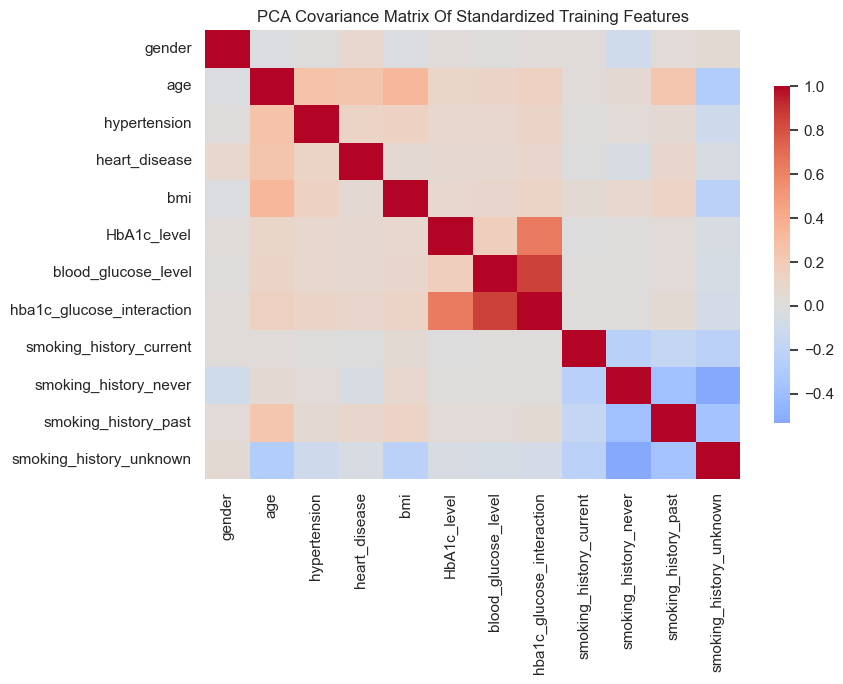

Covariance matrix shape: (12, 12)


,gender,age,hypertension,heart_disease,bmi,HbA1c_level,blood_glucose_level,hba1c_glucose_interaction,smoking_history_current,smoking_history_never,smoking_history_past,smoking_history_unknown
gender,1.000,-0.020,0.017,0.081,-0.020,0.024,0.018,0.026,0.027,-0.097,0.036,0.051
age,-0.020,1.000,0.259,0.242,0.337,0.107,0.114,0.152,0.028,0.060,0.233,-0.279
hypertension,0.017,0.259,1.000,0.123,0.147,0.081,0.081,0.110,0.014,0.041,0.064,-0.106
heart_disease,0.081,0.242,0.123,1.000,0.058,0.068,0.070,0.096,0.003,-0.037,0.094,-0.045
bmi,-0.020,0.337,0.147,0.058,1.000,0.082,0.093,0.122,0.052,0.083,0.127,-0.225
HbA1c_level,0.024,0.107,0.081,0.068,0.082,1.000,0.173,0.630,0.003,0.009,0.037,-0.042
blood_glucose_level,0.018,0.114,0.081,0.070,0.093,0.173,1.000,0.857,0.010,0.012,0.038,-0.051
hba1c_glucose_interaction,0.026,0.152,0.110,0.096,0.122,0.630,0.857,1.000,0.009,0.014,0.051,-0.064
smoking_history_current,0.027,0.028,0.014,0.003,0.052,0.003,0.010,0.009,1.000,-0.245,-0.168,-0.234
smoking_history_never,-0.097,0.060,0.041,-0.037,0.083,0.009,0.012,0.014,-0.245,1.000,-0.383,-0.533


In [52]:
# PCA is fitted only on the training data to avoid data leakage.
# Lecture 10: after preprocessing, compute covariance matrix for zero-mean data.
pca_input_scaler = StandardScaler()
X_train_pca_ready = pd.DataFrame(
    pca_input_scaler.fit_transform(X_train),
    columns=X_train.columns,
    index=X_train.index,
)
X_val_pca_ready = pd.DataFrame(
    pca_input_scaler.transform(X_val),
    columns=X_val.columns,
    index=X_val.index,
)
X_test_pca_ready = pd.DataFrame(
    pca_input_scaler.transform(X_test),
    columns=X_test.columns,
    index=X_test.index,
)

# sklearn data is shaped (m examples x n features), so Cov = X.T @ X / (m - 1).
cov_matrix = np.cov(X_train_pca_ready, rowvar=False)
cov_df = pd.DataFrame(cov_matrix, index=X_train_pca_ready.columns, columns=X_train_pca_ready.columns)

fig, ax = plt.subplots(figsize=(9, 7))
sns.heatmap(cov_df, cmap="coolwarm", center=0, ax=ax, cbar_kws={"shrink": 0.75})
ax.set_title("PCA Covariance Matrix Of Standardized Training Features")
plt.tight_layout()
plt.show()

print(f"Covariance matrix shape: {cov_matrix.shape}")
display(cov_df.round(3))

### PCA_2 Eigenvalues And Eigenvectors


,PC,Eigenvalue,Explained Variance,Cumulative Variance
0,1,2.4318,0.2026,0.2026
1,2,1.7481,0.1457,0.3483
2,3,1.4903,0.1242,0.4725
3,4,1.1421,0.0952,0.5677
4,5,1.0789,0.0899,0.6576
5,6,0.9805,0.0817,0.7393
6,7,0.8765,0.0730,0.8123
7,8,0.8343,0.0695,0.8819
8,9,0.8227,0.0686,0.9504
9,10,0.5814,0.0484,0.9989


Top eigenvectors / feature loadings for the first principal components:


,PC1,PC2,PC3,PC4,PC5
gender,-0.0157,0.0986,0.2206,0.0739,0.3198
age,-0.3389,-0.3430,0.1926,-0.0436,0.1729
hypertension,-0.2223,-0.1771,0.1044,-0.0225,0.4525
heart_disease,-0.1814,-0.0893,0.2499,-0.0946,0.5157
bmi,-0.2691,-0.2945,0.0613,0.0832,0.0132
HbA1c_level,-0.3649,0.2566,-0.0714,-0.0116,-0.0164
blood_glucose_level,-0.4460,0.3390,-0.1156,0.0138,-0.1011
hba1c_glucose_interaction,-0.5355,0.3882,-0.1222,0.0040,-0.0823
smoking_history_current,-0.0336,-0.0352,0.1076,0.9153,-0.0352
smoking_history_never,-0.0856,-0.3175,-0.6948,-0.1475,0.1365


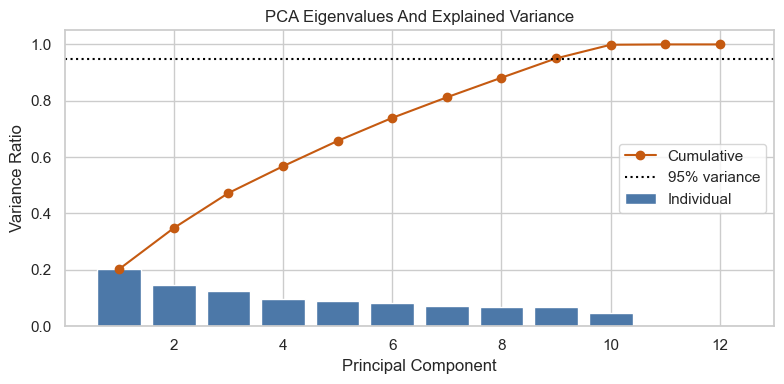

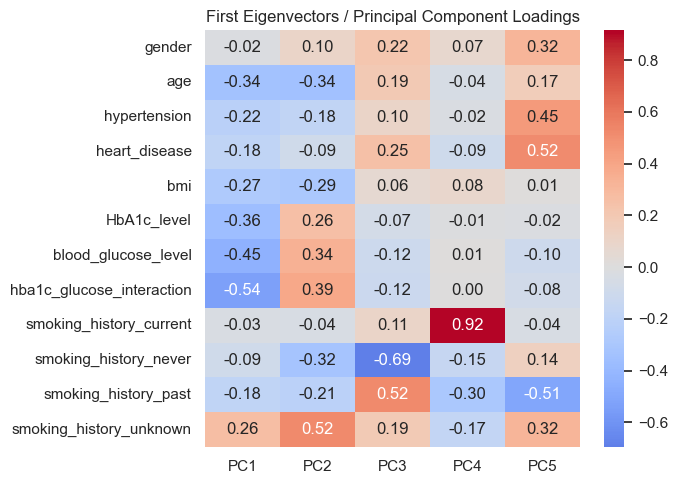

In [53]:
# Lecture 10: calculate eigenvectors and eigenvalues of the covariance matrix.
# The covariance matrix is symmetric, so eigh is stable and appropriate.
eigenvalues, eigenvectors = np.linalg.eigh(cov_matrix)
sort_idx = np.argsort(eigenvalues)[::-1]
eigenvalues = eigenvalues[sort_idx]
eigenvectors = eigenvectors[:, sort_idx]

explained_variance_ratio = eigenvalues / eigenvalues.sum()
cumulative_variance = np.cumsum(explained_variance_ratio)

eigen_table = pd.DataFrame({
    "PC": np.arange(1, len(eigenvalues) + 1),
    "Eigenvalue": eigenvalues,
    "Explained Variance": explained_variance_ratio,
    "Cumulative Variance": cumulative_variance,
})

display(eigen_table.round(4))

top_eigenvectors = pd.DataFrame(
    eigenvectors[:, :min(5, eigenvectors.shape[1])],
    index=X_train_pca_ready.columns,
    columns=[f"PC{i}" for i in range(1, min(5, eigenvectors.shape[1]) + 1)],
)

print("Top eigenvectors / feature loadings for the first principal components:")
display(top_eigenvectors.round(4))

fig, ax = plt.subplots(figsize=(8, 4))
ax.bar(eigen_table["PC"], eigen_table["Explained Variance"], color="#4C78A8", label="Individual")
ax.plot(eigen_table["PC"], eigen_table["Cumulative Variance"], marker="o", color="#C55A11", label="Cumulative")
ax.axhline(0.95, color="black", ls=":", label="95% variance")
ax.set_title("PCA Eigenvalues And Explained Variance")
ax.set_xlabel("Principal Component")
ax.set_ylabel("Variance Ratio")
ax.legend()
plt.tight_layout()
plt.show()

fig, ax = plt.subplots(figsize=(7, 5))
sns.heatmap(top_eigenvectors, cmap="coolwarm", center=0, annot=True, fmt=".2f", ax=ax)
ax.set_title("First Eigenvectors / Principal Component Loadings")
plt.tight_layout()
plt.show()

### PCA_3 Choose Best k And Project Data


In [54]:
# Choose k as the smallest number of principal components that keeps at least 95% variance.
# This follows the lecture idea: keep the first k eigenvectors with the largest eigenvalues.
n_components_95 = int(np.searchsorted(cumulative_variance, 0.95) + 1)
variance_kept = cumulative_variance[n_components_95 - 1]

print(f"Chosen k = {n_components_95}")
print(f"Reason: first {n_components_95} components preserve {variance_kept:.2%} of total variance.")
print(f"Original feature count = {X_train_pca_ready.shape[1]}, PCA feature count = {n_components_95}")

U_reduced = eigenvectors[:, :n_components_95]

# Lecture notation: Z_i = U_reduced.T X_i.
# With rows as examples in sklearn: Z = X @ U_reduced.
X_train_pca = X_train_pca_ready.to_numpy() @ U_reduced
X_val_pca = X_val_pca_ready.to_numpy() @ U_reduced
X_test_pca = X_test_pca_ready.to_numpy() @ U_reduced

print(f"X_train_pca shape: {X_train_pca.shape}")
print(f"X_val_pca shape:   {X_val_pca.shape}")
print(f"X_test_pca shape:  {X_test_pca.shape}")

Chosen k = 9
Reason: first 9 components preserve 95.04% of total variance.
Original feature count = 12, PCA feature count = 9
X_train_pca shape: (66652, 9)
X_val_pca shape:   (9522, 9)
X_test_pca shape:  (19044, 9)


### PCA_4 Train Highest-F1 Model With PCA


In [55]:
pre_pca_summary = comparison_table()
best_pre_pca_row = pre_pca_summary[~pre_pca_summary["model"].str.contains("PCA", regex=False)].sort_values(
    ["test_f1", "test_recall", "test_precision"],
    ascending=False,
).iloc[0]

best_pre_pca_name = best_pre_pca_row["model"]
best_pre_pca_model = model_registry[best_pre_pca_name]["model"]

print("Highest-F1 model before PCA:")
display(best_pre_pca_row[[
    "model", "test_f1", "test_precision", "test_recall",
    "test_accuracy", "train_val_f1_gap"
]].to_frame().T.round(4))

best_pca_model = clone(best_pre_pca_model)
best_pca_model.fit(X_train_pca, y_train)
pca_model_name = f"{best_pre_pca_name} PCA ({n_components_95})"

evaluate_and_register(
    pca_model_name,
    best_pca_model,
    X_train_pca, y_train,
    X_val_pca, y_val,
    X_test_pca, y_test,
    notes=f"Lecture-style PCA using highest-F1 model before PCA: {best_pre_pca_name}",
)
display(model_summary(pca_model_name))

Highest-F1 model before PCA:


,model,test_f1,test_precision,test_recall,test_accuracy,train_val_f1_gap
12,Random Forest,0.762655,0.729032,0.799528,0.955682,0.051621


Random Forest PCA (9) selected threshold: 0.526
Threshold rule: max F1 with recall >= 80%, precision tie-break
Validation threshold effect: default F1=0.6924, P=0.5969, R=0.8243 | tuned F1=0.7038, P=0.6257, R=0.8042


,f1,precision,recall,accuracy,roc_auc
train,0.797879,0.701636,0.924722,0.958261,0.992442
validation,0.703818,0.625688,0.804245,0.939719,0.971875
test,0.709227,0.631385,0.808962,0.940926,0.971397


,model,threshold,train_f1,val_f1,test_f1,test_precision,test_recall,test_accuracy,test_roc_auc,train_val_f1_gap,recall_target_met,notes
0,Random Forest PCA (9),0.526,0.7979,0.7038,0.7092,0.6314,0.809,0.9409,0.9714,0.0941,True,Lecture-style PCA using highest-F1 model befor...


### PCA_5 PCA Versus No PCA


In [56]:
pca_rows = comparison_table()
display(pca_rows[pca_rows["model"].isin([best_pre_pca_name, pca_model_name])][[
    "model", "test_f1", "test_precision", "test_recall",
    "test_accuracy", "test_roc_auc", "train_val_f1_gap"
]].round(4))

print(
    "Note: PCA is unsupervised and ignores the target label. "
    "It may reduce dimensionality, but it is not guaranteed to improve F1-score."
)

,model,test_f1,test_precision,test_recall,test_accuracy,test_roc_auc,train_val_f1_gap
12,Random Forest,0.7627,0.7290,0.7995,0.9557,0.9778,0.0516
15,Random Forest PCA (9),0.7092,0.6314,0.8090,0.9409,0.9714,0.0941


Note: PCA is unsupervised and ignores the target label. It may reduce dimensionality, but it is not guaranteed to improve F1-score.


## 11. Final Comparison And Best Model


### FINAL_1 Comparison Table


In [57]:
summary = comparison_table()
display(summary[[
    "model", "threshold", "test_f1", "test_precision", "test_recall",
    "test_accuracy", "test_roc_auc", "train_val_f1_gap", "recall_target_met"
]].round(4))


,model,threshold,test_f1,test_precision,test_recall,test_accuracy,test_roc_auc,train_val_f1_gap,recall_target_met
12,Random Forest,0.612,0.7627,0.7290,0.7995,0.9557,0.9778,0.0516,False
4,MLP,0.704,0.7338,0.6734,0.8060,0.9479,0.9737,0.0190,True
14,AdaBoost,0.514,0.7219,0.6503,0.8113,0.9443,0.9736,-0.0012,True
15,Random Forest PCA (9),0.526,0.7092,0.6314,0.8090,0.9409,0.9714,0.0941,True
7,SVM RBF Grid Search,0.666,0.6872,0.6123,0.7830,0.9365,0.9513,0.0195,False
2,Logistic Regression,0.692,0.6806,0.5931,0.7983,0.9333,0.9619,-0.0073,False
8,SVM RBF PSO,0.612,0.6470,0.5524,0.7807,0.9241,0.9256,0.0469,False
6,SVM Linear,0.472,0.6443,0.5285,0.8249,0.9189,0.9608,-0.0677,True
10,Naive Bayes,0.456,0.5483,0.4153,0.8066,0.8816,0.9342,-0.0052,True


### FINAL_2 Metric Comparison Chart


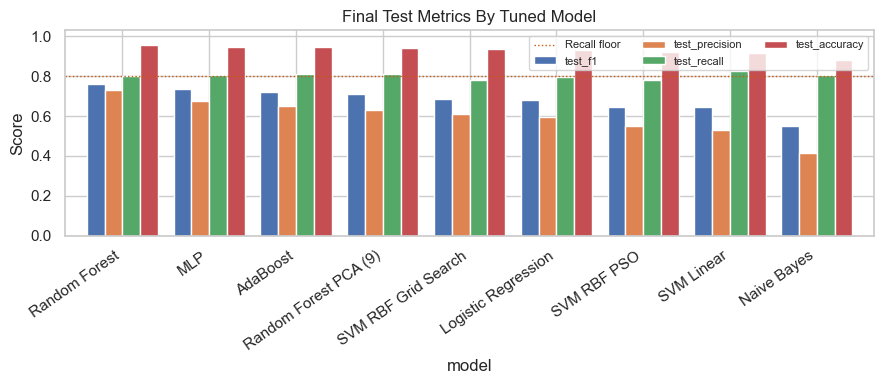

In [58]:
ax = summary.set_index("model")[["test_f1", "test_precision", "test_recall", "test_accuracy"]].plot(
    kind="bar", figsize=(9, 4), width=0.82
)
ax.axhline(MIN_RECALL, color="#C55A11", ls=":", lw=1, label="Recall floor")
ax.set_ylim(0, 1.03)
ax.set_title("Final Test Metrics By Tuned Model")
ax.set_ylabel("Score")
ax.legend(ncol=3, fontsize=8)
plt.xticks(rotation=35, ha="right")
plt.tight_layout()
plt.show()


### FINAL_3 ROC Curves


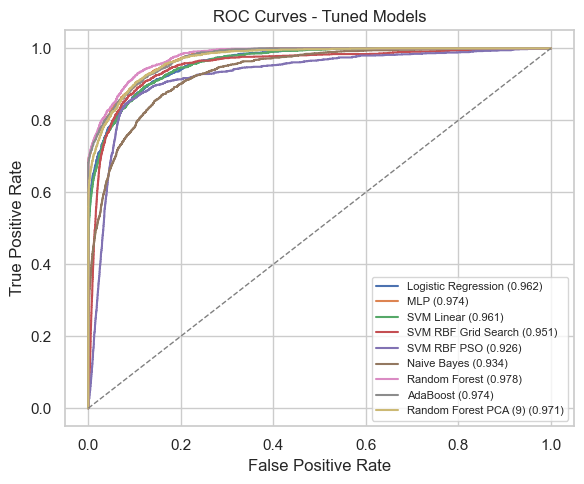

In [59]:
fig, ax = plt.subplots(figsize=(6, 5))
for name, item in model_registry.items():
    if "Baseline" in name:
        continue
    scores = get_scores(item["model"], item["X_test"])
    fpr, tpr, _ = roc_curve(item["y_test"], scores)
    auc = roc_auc_score(item["y_test"], scores)
    ax.plot(fpr, tpr, lw=1.5, label=f"{name} ({auc:.3f})")
ax.plot([0, 1], [0, 1], ls="--", color="gray", lw=1)
ax.set_title("ROC Curves - Tuned Models")
ax.set_xlabel("False Positive Rate")
ax.set_ylabel("True Positive Rate")
ax.legend(fontsize=8)
plt.tight_layout()
plt.show()

### FINAL_4 Best Model Selection And Save


In [60]:
selection_pool = summary[~summary["model"].str.contains("Baseline", regex=False)].copy()
best_row = selection_pool.sort_values(["test_f1", "test_recall", "test_precision"], ascending=False).iloc[0]
best_name = best_row["model"]
best_item = model_registry[best_name]

print("=" * 72)
print("BEST MODEL BY HIGHEST TEST F1-SCORE")
print("=" * 72)
if not bool(best_row["recall_target_met"]):
    print(f"Warning: {best_name} has the highest F1, but test recall is below the {MIN_RECALL:.0%} target.")
    print("Check the final table if you need to choose the best model that strictly meets recall >= 80%.")
best_display_cols = [
    "model", "threshold", "test_f1", "test_precision", "test_recall",
    "test_accuracy", "test_roc_auc", "train_val_f1_gap", "recall_target_met"
]
best_display = best_row[best_display_cols].to_frame().T
numeric_cols = best_display.select_dtypes(include="number").columns
best_display[numeric_cols] = best_display[numeric_cols].round(4)
print(best_display.to_string(index=False))

artifact = {
    "model_name": best_name,
    "estimator": best_item["model"],
    "threshold": float(best_item["threshold"]),
    "scaler": scaler,
    "feature_columns": X_train_scaled.columns.tolist(),
    "continuous_features": continuous_features,
    "metrics": best_item["metrics"],
    "min_recall_target": MIN_RECALL,
}

if "PCA" in best_name:
    artifact["pca_input_scaler"] = pca_input_scaler
    artifact["pca_U_reduced"] = U_reduced
    artifact["pca_n_components"] = int(n_components_95)

joblib.dump(artifact, "best_diabetes_model.joblib")
print(f"Saved best model artifact to best_diabetes_model.joblib ({os.path.getsize('best_diabetes_model.joblib') / 1024:.1f} KB)")

BEST MODEL BY HIGHEST TEST F1-SCORE
Check the final table if you need to choose the best model that strictly meets recall >= 80%.
        model threshold   test_f1 test_precision test_recall test_accuracy test_roc_auc train_val_f1_gap recall_target_met
Random Forest     0.612  0.762655       0.729032    0.799528      0.955682     0.977819         0.051621             False
Saved best model artifact to best_diabetes_model.joblib (16996.3 KB)
